# Day 14: Testing + Tuning the Matcher

Goals:
1. Run matcher against several projects
2. Inspect score breakdowns
3. Tune thresholds
4. Visualise score distributions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append("../src")
from matcher import Matcher

matcher = Matcher()
matcher.load()
print("✅ Matcher ready")

  Loading Matcher...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  ✅ Loaded 80 employees, 30 projects
✅ Matcher ready


## 1. Test Against Multiple Projects

In [2]:
# Test 5 different projects + different roles
test_cases = [
    ("P001", "Backend Dev"),
    ("P002", "ML Engineer"),
    ("P003", "Data Scientist"),
    ("P004", "DevOps"),
    ("P005", "Android Dev"),
]

all_results = {}
for pid, role in test_cases:
    results = matcher.match(pid, role, top_k=5, verbose=False)
    all_results[(pid, role)] = results
    eligible = results[results["eligible"]]
    top1     = eligible.iloc[0] if len(eligible) > 0 else None
    print(f"\n{pid} | {role:<18} | "
          f"Eligible: {len(eligible):2d} | "
          f"Top match: {top1['name'] if top1 is not None else 'NONE':<18}"
          f" score={top1['final_score'] if top1 is not None else 0:.4f}")


P001 | Backend Dev        | Eligible: 58 | Top match: Ikbal Kothari      score=0.8558

P002 | ML Engineer        | Eligible: 68 | Top match: Theodore Devi      score=0.8383

P003 | Data Scientist     | Eligible: 58 | Top match: Isaac Patil        score=0.8089

P004 | DevOps             | Eligible: 68 | Top match: Nitesh Raghavan    score=0.7773

P005 | Android Dev        | Eligible: 74 | Top match: Harini Choudhury   score=0.8203


## 2. Score Breakdown Visualisation

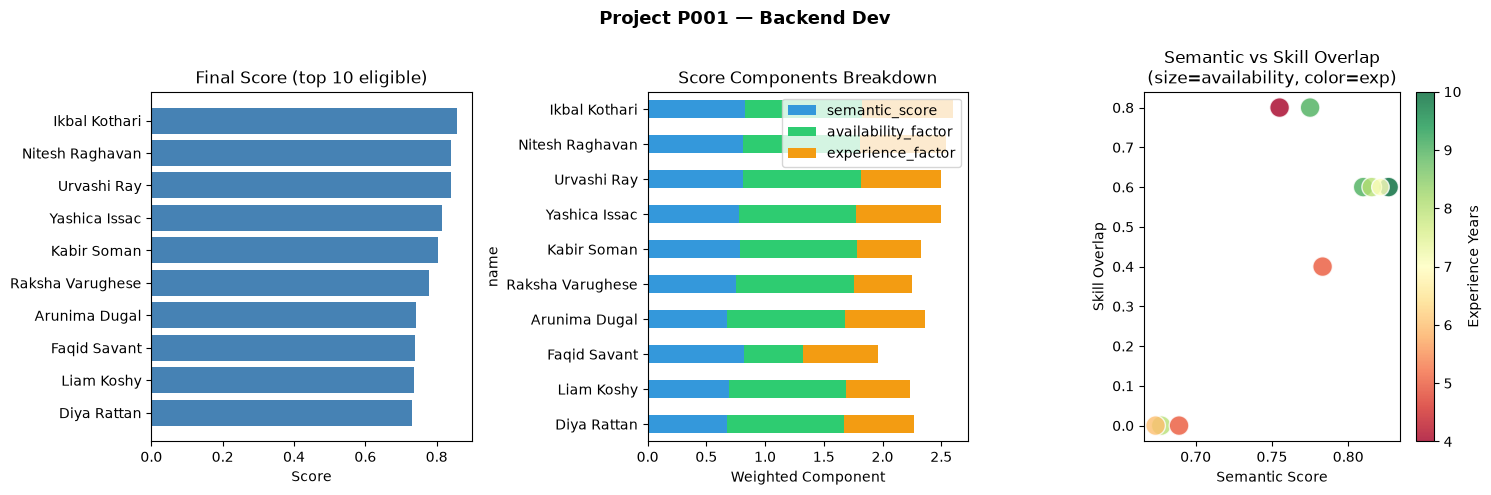

In [3]:
# Deep dive on one project
pid, role = "P001", "Backend Dev"
df = all_results[(pid, role)]
eligible = df[df["eligible"]].head(10).copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Final score bar
axes[0].barh(eligible["name"], eligible["final_score"],
             color="steelblue")
axes[0].set_title("Final Score (top 10 eligible)")
axes[0].set_xlabel("Score"); axes[0].invert_yaxis()

# Score component stacked bar
comp = eligible[["name","semantic_score",
                  "availability_factor","experience_factor"]].set_index("name")
comp.plot(kind="barh", stacked=True, ax=axes[1],
          color=["#3498db","#2ecc71","#f39c12"])
axes[1].set_title("Score Components Breakdown")
axes[1].set_xlabel("Weighted Component")
axes[1].invert_yaxis()

# Skill overlap vs semantic
axes[2].scatter(eligible["semantic_score"],
                eligible["skill_overlap"],
                s=eligible["availability_pct"]*2,
                c=eligible["experience_years"],
                cmap="RdYlGn", alpha=0.8, edgecolors="white")
axes[2].set_xlabel("Semantic Score")
axes[2].set_ylabel("Skill Overlap")
axes[2].set_title("Semantic vs Skill Overlap\n(size=availability, color=exp)")
plt.colorbar(axes[2].collections[0], ax=axes[2], label="Experience Years")

plt.suptitle(f"Project {pid} — {role}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/day14_score_breakdown.png", dpi=150)
plt.show()

## 3. Threshold Tuning

In [4]:
# How many candidates pass at different thresholds?
pid, role = "P002", "ML Engineer"
df = all_results.get((pid, role))
if df is None:
    df = matcher.match(pid, role, top_k=20, verbose=False)

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
print(f"{'Threshold':<12} {'Candidates passing':<20} {'Top score'}")
print("-" * 45)
for t in thresholds:
    passing = df[(df["eligible"]) & (df["final_score"] >= t)]
    top     = df["final_score"].max()
    print(f"  {t:<10}  {len(passing):<20} {top:.4f}")

Threshold    Candidates passing   Top score
---------------------------------------------
  0.3         68                   0.8383
  0.35        67                   0.8383
  0.4         66                   0.8383
  0.45        58                   0.8383
  0.5         52                   0.8383
  0.55        39                   0.8383
  0.6         27                   0.8383


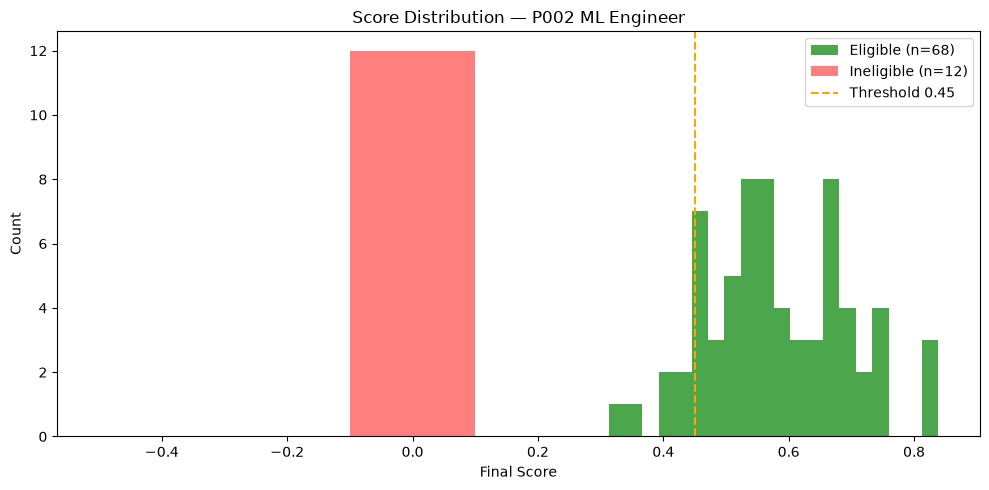

In [5]:
# Full score distribution
fig, ax = plt.subplots(figsize=(10, 5))
eligible = df[df["eligible"]]
ineligible = df[~df["eligible"]]

ax.hist(eligible["final_score"],   bins=20, alpha=0.7,
        color="green", label=f"Eligible (n={len(eligible)})")
ax.hist(ineligible["final_score"], bins=5,  alpha=0.5,
        color="red",   label=f"Ineligible (n={len(ineligible)})")
ax.axvline(x=0.45, color="orange", linestyle="--", label="Threshold 0.45")
ax.set_xlabel("Final Score"); ax.set_ylabel("Count")
ax.set_title(f"Score Distribution — {pid} {role}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/day14_score_distribution.png", dpi=150)
plt.show()

## 4. Tests for Edge Cases

In [6]:
# Edge case 1: project where roles are hard to fill
print("=== Edge Case: Very high min experience ===")
hard_proj = matcher.proj_df.iloc[0]["project_id"]
df_hard   = matcher.match(hard_proj, "ML Engineer",
                           top_k=5, verbose=False)
eligible  = df_hard[df_hard["eligible"]]
print(f"Eligible candidates: {len(eligible)}")
if len(eligible) == 0:
    print("⚠️  WARNING: No eligible candidates found!")
    print("   → Optimizer will flag this as infeasible")
    print("   → Dashboard will show 'No match found' message")
else:
    print(eligible[["name","role","experience_years",
                     "availability_pct","final_score"]].head(5).to_string(index=False))

=== Edge Case: Very high min experience ===
Eligible candidates: 58
            name          role  experience_years  availability_pct  final_score
   Theodore Devi   ML Engineer                 5               100       0.8428
   Priya Rastogi   ML Engineer                 8               100       0.8358
   Ekavir Varkey Data Engineer                 4               100       0.7624
Gayathri Chaudry   ML Engineer                 8                80       0.7568
     Unni Bhagat Data Engineer                 5               100       0.7440


In [7]:
# Edge case 2: All roles for a project
print("\n=== All Roles — Full Project Match ===")
all_role_results = matcher.match_all_roles("P003", top_k=3)

print("\n── Summary ──")
for role, rdf in all_role_results.items():
    n_elig = len(rdf[rdf["eligible"]])
    top    = rdf[rdf["eligible"]].iloc[0] if n_elig > 0 else None
    print(f"  {role:<20} | eligible: {n_elig:2d} | "
          f"best: {top['name'] if top is not None else 'NONE'}")


=== All Roles — Full Project Match ===

Matching all roles for project: P003
Roles required: ['Android Dev', 'Backend Dev', 'Data Engineer']

Project: iOS Banking App — Axis Bank Tech
Role:    Android Dev  |  Min exp: 4yr  |  Min avail: 60%
Query:   'Android Dev with skills in Swift, iOS, REST APIs, PostgreSQL, AWS. Minimum 4 years experience.'

 rank            name        role  experience_years  availability_pct  skill_overlap  semantic_score  final_score
    1      Logan Sami Android Dev                 7                80            0.2          0.8281       0.7433
    2 Nitesh Raghavan Backend Dev                 9               100            0.6          0.6593       0.7343
    3   Ikbal Kothari Backend Dev                10               100            0.6          0.6385       0.7242

Project: iOS Banking App — Axis Bank Tech
Role:    Backend Dev  |  Min exp: 4yr  |  Min avail: 60%
Query:   'Backend Dev with skills in Swift, iOS, REST APIs, PostgreSQL, AWS. Minimum 4 years ex

In [8]:
# Save score matrix for optimizer (Week 3 will consume this)
print("\n=== Building Score Matrix for Week 3 ===")
proj_df = matcher.proj_df.copy()
score_records = []

for _, proj in proj_df.head(5).iterrows():        # first 5 projects
    roles = [r.strip() for r in proj["required_roles"].split(";")]
    for role in roles:
        role_scores = matcher.match(
            proj["project_id"], role, top_k=999, verbose=False
        )
        for _, emp_row in role_scores.iterrows():
            score_records.append({
                "project_id":  proj["project_id"],
                "role":        role,
                "employee_id": emp_row["employee_id"],
                "final_score": emp_row["final_score"],
                "eligible":    emp_row["eligible"],
            })

score_matrix_df = pd.DataFrame(score_records)
score_matrix_df.to_csv("../data/processed/score_matrix.csv", index=False)
print(f"✅ Saved score_matrix.csv ({len(score_matrix_df)} rows)")
print("   Week 3 optimizer will consume this file.")


=== Building Score Matrix for Week 3 ===
✅ Saved score_matrix.csv (1120 rows)
   Week 3 optimizer will consume this file.


## ✅ Week 2 Sprint Retro

**Sprint Goal ACHIEVED:**
> Given a project requirement → produce a ranked, scored shortlist of candidates ✅

**What we built:**
- Day 8:  Embedding concepts + model setup
- Day 9:  Embedded 80 employees + 30 projects into FAISS
- Day 10: Vector store with fast top-k search
- Day 11: KMeans clustering (elbow + silhouette)
- Day 12: Cluster validation (role purity heatmap)
- Day 13: Full match scoring (semantic + availability + experience)
- Day 14: Tested on 5 projects, tuned thresholds, saved score_matrix.csv

**Next Sprint (Week 3):** OR-Tools optimizer — turn scores into conflict-free staffing plans